# Econometrics I

```
TA Christian Alemán
```

**Session 3: Friday 4, February 2022**

**Activity 1: Random Sampling**

Simulate a Population

$$x\sim\mathcal{N}(\mu,\sigma^{2})$$

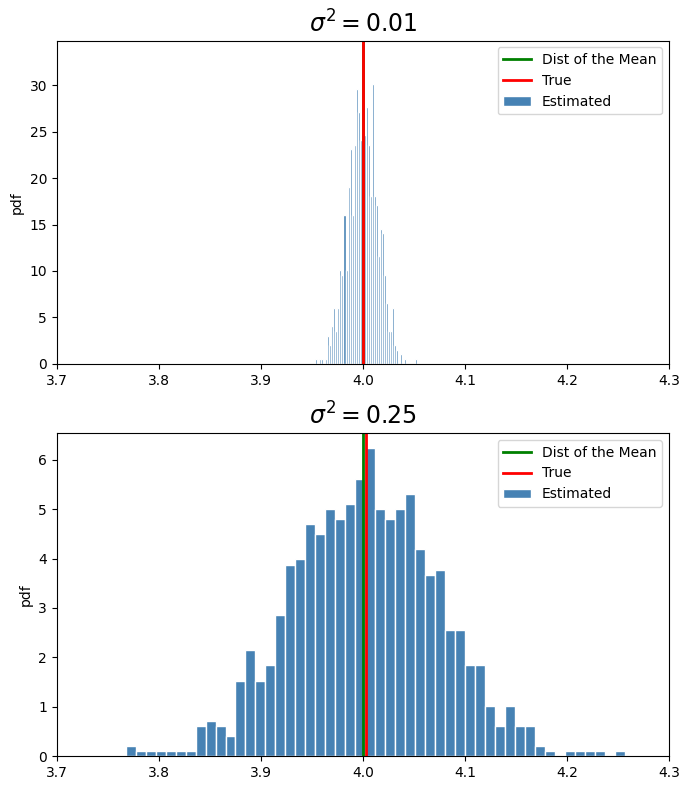

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import warnings

rng = np.random.default_rng(1234)   # Set seed for reproducibility

# Plot options
num_bins = 50

N  = 1_000_000     # Our Universe
NS = 50             # Size of our sample
MS = 1000           # Number of samples
sigma = [0.1, 0.5]
mu = 4

x_vec = np.empty((N, 2))
x_sample = np.empty((NS, MS, 2))
x_mean = np.empty((MS, 2))
y_sample = np.empty((NS, MS, 2))
y_mean = np.empty((MS, 2))

for i in range(2):
    x_vec[:, i] = mu + sigma[i] * rng.standard_normal(N)

    # With loop: generate NS samples from the universe
    for j in range(MS):
        x_sample[:, j, i] = rng.choice(x_vec[:, i], size=NS, replace=False)
        x_mean[j, i] = x_sample[:, j, i].mean()

    # Without a loop, purely for Montecarlo purposes:
    y_sample[:, :, i] = mu + sigma[i] * rng.standard_normal((NS, MS))
    y_mean[:, i] = y_sample[:, :, i].mean(axis=0)

# Plot the Distribution of Means and the true mean
fig, axes = plt.subplots(2, 1, figsize=(7, 8))
for i in range(2):
    ax = axes[i]
    ax.hist(x_mean[:, i], bins=num_bins, density=True, color='steelblue', edgecolor='white')
    ax.axvline(mu, color='g', linewidth=2, label='True')
    ax.axvline(x_mean[:, i].mean(), color='r', linewidth=2, label='Estimated')
    ax.set_title(rf'$\sigma^{{2}} = ${round(sigma[i]**2, 6)}', fontsize=17)
    ax.set_xlim(3.7, 4.3)
    ax.set_ylabel('pdf')
    ax.legend(['Dist of the Mean', 'True', 'Estimated'])
plt.tight_layout()
plt.show()


Do the same for the generalized pareto:

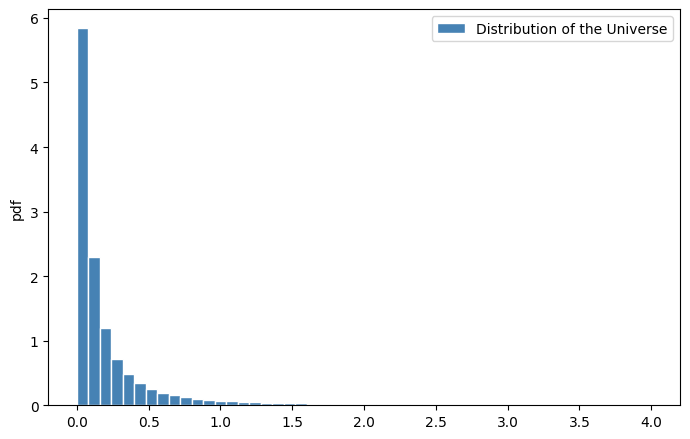

In [2]:
rng = np.random.default_rng(567)   # Set seed for reproducibility

sigma_gp = 0.1   # Scale
k_gp = 0.8       # Index, shape
theta_gp = 0     # Threshold, location
x_vec = stats.genpareto.rvs(c=k_gp, loc=theta_gp, scale=sigma_gp, size=N, random_state=rng)

MS = 2000
NS = 200          # Size of our sample
mu_A = theta_gp + (2**k_gp - 1) * sigma_gp / k_gp
mu_B = theta_gp + sigma_gp / (1 - k_gp)

x_sample = np.empty((NS, MS))
x_mean = np.empty(MS)
x_median = np.empty(MS)

# Plot the histogram of the distribution of the Universe
mask = x_vec <= 4
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(x_vec[mask], bins=num_bins, density=True, color='steelblue', edgecolor='white', label='Distribution of the Universe')
ax.set_ylabel('pdf')
ax.legend()
plt.tight_layout()
plt.show()

for j in range(MS):
    x_sample[:, j] = rng.choice(x_vec, size=NS, replace=False)
    x_median[j] = np.median(x_sample[:, j])
    x_mean[j] = x_sample[:, j].mean()


Plot the Distribution of Medians

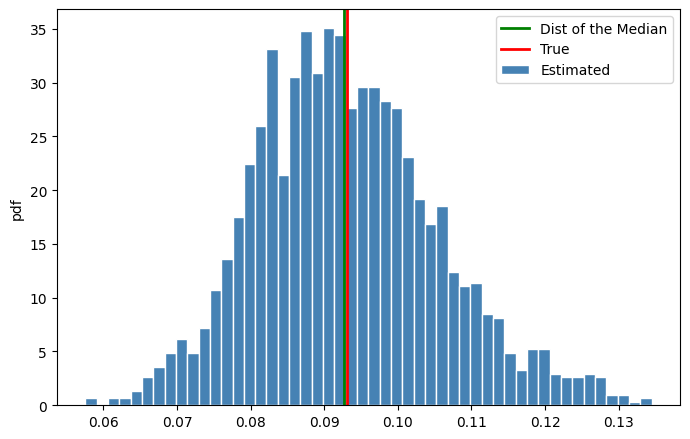

In [3]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(x_median, bins=num_bins, density=True, color='steelblue', edgecolor='white')
ax.axvline(mu_A, color='g', linewidth=2)
ax.axvline(x_median.mean(), color='r', linewidth=2)
ax.set_ylabel('pdf')
ax.legend(['Dist of the Median', 'True', 'Estimated'])
plt.tight_layout()
plt.show()


**Activity 2: Backing out Residuals**

$$y = \beta_{0} + \beta_{1} x + e \quad \text{Where} \quad e\sim \mathcal{N}(0,\sigma^{2})$$

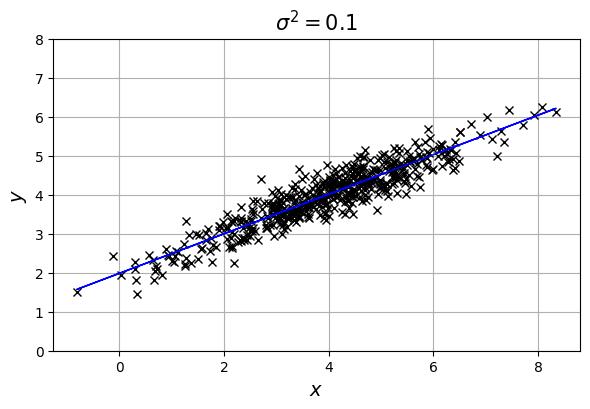

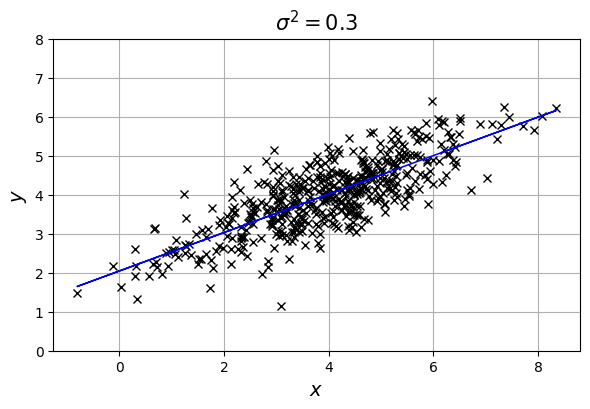

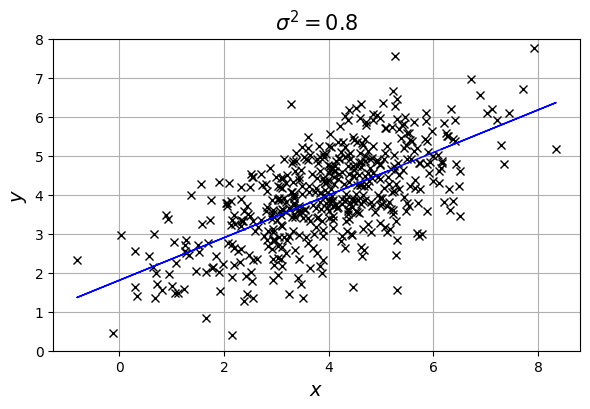

In [4]:
def ols_esti(y, X):
    '''
    This function computes the Least Squares Estimate
    Input:
    y: Dependent Variable    (N,1)
    X: Independent Variables (N,K)
    Output:
    Many stuff you saw in class.
    '''
    y = np.asarray(y, dtype=float)
    X = np.asarray(X, dtype=float)
    Nx, K = X.shape
    Ny = y.shape[0]
    if Ny != Nx:
        raise ValueError('X and y do not have the same length')
    if np.linalg.matrix_rank(X.T @ X) != K:
        raise ValueError('Not complete Rank, Perfect Colinearity')
    N = Nx

    # Coefficients:
    beta_hat = np.linalg.inv(X.T @ X) @ (X.T @ y)
    # Predicted values:
    y_hat = X @ beta_hat
    # Residuals:
    e_hat = y - y_hat
    # Total Variation of the dependent variable
    SST = (y - y.mean()) @ (y - y.mean())
    # (SSE) Sum Squared Residuals
    SSE = e_hat @ e_hat
    # SSR/SST or "r-squared" is the ratio of the variation in y explained by the model and the total variation of y
    R2 = 1 - (SSE / SST)
    # Adjusted "r-squared".
    R2A = 1 - (SSE / (N - K)) / (SST / (N - 1))
    sigma2_hat = SSE / (N - K)

    var_covar = sigma2_hat * np.linalg.inv(X.T @ X)
    SEbeta_hat = np.sqrt(np.diag(var_covar))

    return {
        'beta_hat': beta_hat, 'y_hat': y_hat, 'e_hat': e_hat,
        'SST': SST, 'SSE': SSE, 'R2': R2, 'R2A': R2A, 'sigma2_hat': sigma2_hat,
        'var_covar': var_covar, 'SEbeta_hat': SEbeta_hat,
    }

rng = np.random.default_rng(4567)

n = 500
mean_x1, variance_x = 4.0, 2.0
variance_e = [0.1, 0.3, 0.8]
x = mean_x1 + np.sqrt(variance_x) * rng.standard_normal(n)

beta0, beta1 = 2.0, 0.5

err = np.empty((n, 3))
y = np.empty((n, 3))
X_design = np.column_stack([np.ones(n), x])
results = []
for i in range(3):
    err[:, i] = 0 + np.sqrt(variance_e[i]) * rng.standard_normal(n)
    # Simulate Data Generating Process:
    y[:, i] = beta0 + beta1 * x + err[:, i]
    # Estimate the OLS and back out the Residuals
    results.append(ols_esti(y[:, i], X_design))

for i in range(3):
    fig, ax = plt.subplots(figsize=(6, 4.2))
    ax.plot(x, y[:, i], 'kx')
    ax.plot(x, results[i]['y_hat'], 'b-', linewidth=1.1)
    ax.set_ylim(0, 8)
    ax.grid(True)
    ax.set_xlabel('$x$', fontsize=14)
    ax.set_ylabel('$y$', fontsize=14)
    ax.set_title(rf'$\sigma^{{2}} = ${variance_e[i]}', fontsize=15)
    plt.tight_layout()
    plt.show()


Plot the distribution of the residuals

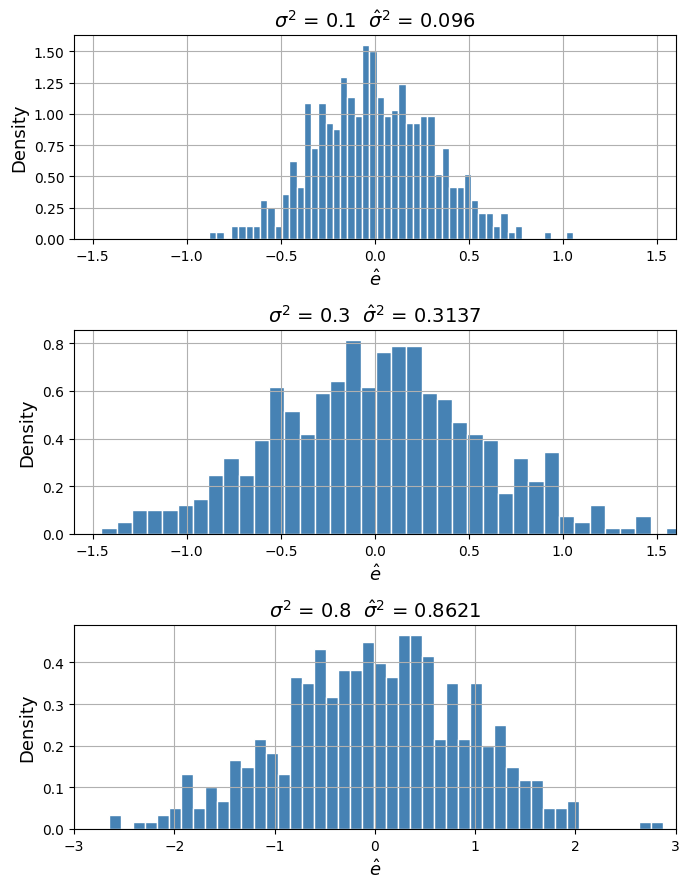

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(7, 9))
xlims = [(-1.6, 1.6), (-1.6, 1.6), (-3, 3)]
for i in range(3):
    ax = axes[i]
    e_hat = results[i]['e_hat']
    ax.hist(e_hat, bins=num_bins, density=True, color='steelblue', edgecolor='white')
    ax.grid(True)
    ax.set_ylabel('Density', fontsize=13)
    ax.set_xlabel(r'$\hat{e}$', fontsize=13)
    ax.set_title(rf'$\sigma^{{2}}$ = {variance_e[i]}  $\hat{{\sigma}}^{{2}}$ = {round(e_hat.var(ddof=0), 4)}', fontsize=14)
    ax.set_xlim(xlims[i])
plt.tight_layout()
plt.show()


**Activity 3: Understanding Collinearity**

$$y = \beta_{0} + \beta_{1} x_{1} + \beta_{2} x_{2} + \epsilon \quad \text{Where} \quad \epsilon\sim \mathcal{N}(0,\sigma^{2}_{\epsilon})$$

and $X = (x_{1}, x_{2})'$ where $X \sim \mathcal{N}(\mu,\Sigma)$ with $\Sigma = \left[\begin{array}{cc}\sigma^{2}_{x_{1}} & \rho\sigma_{x_{1}}\sigma_{x_{2}} \\ \rho\sigma_{x_{1}}\sigma_{x_{2}} & \sigma_{x_{2}}^{2} \end{array}\right]$

Some Parameters we can play with:

1. Number of Samples
2. Variance of the error $\sigma^{2}_{\epsilon}$
3. Variance of x $\sigma^{2}_{x_{1}}$
4. Correlation $\rho$ between $x_{1}$ and $x_{2}$

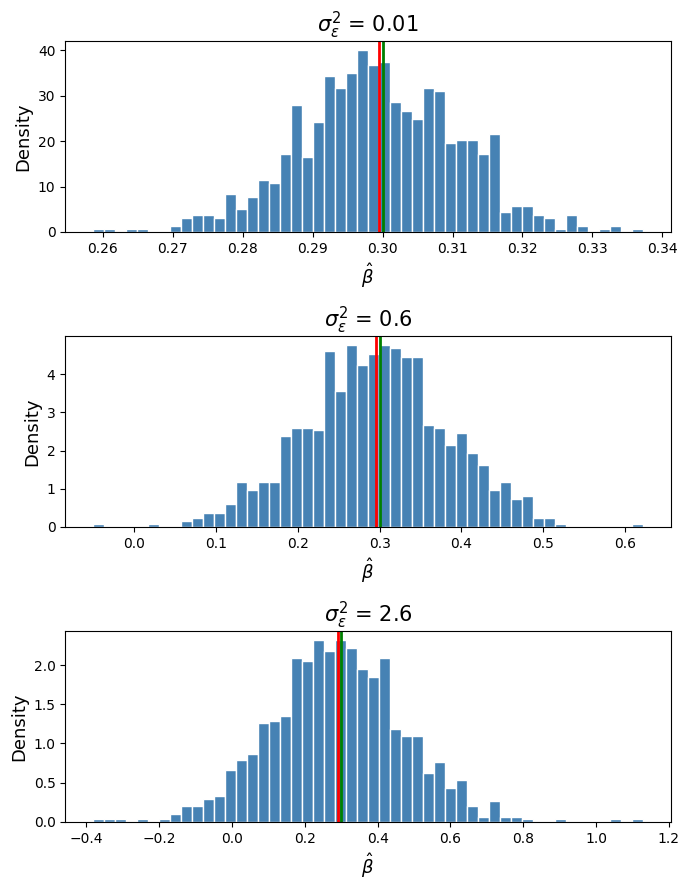

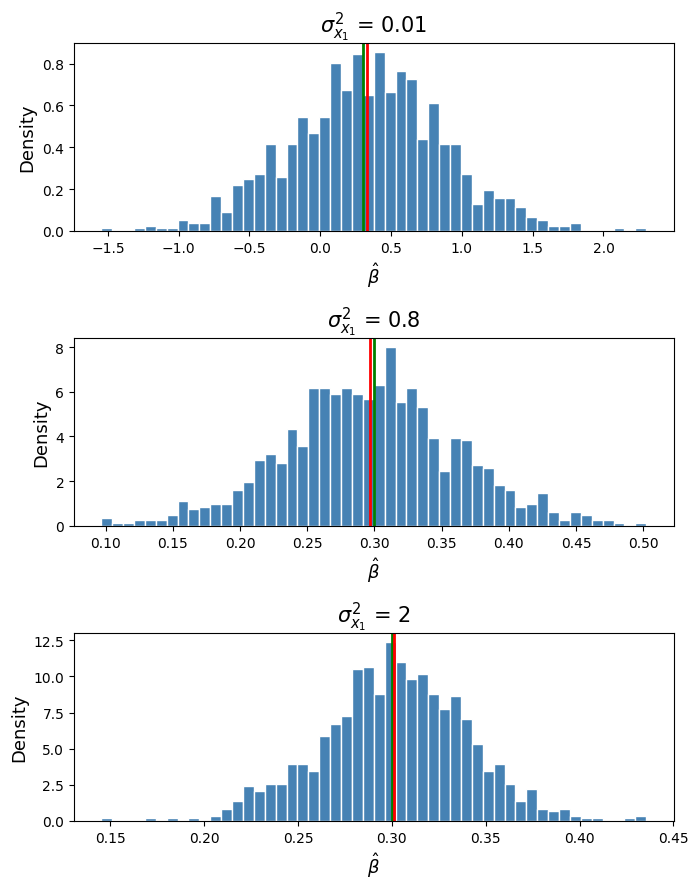

Perfect Colinearity, check your variables!


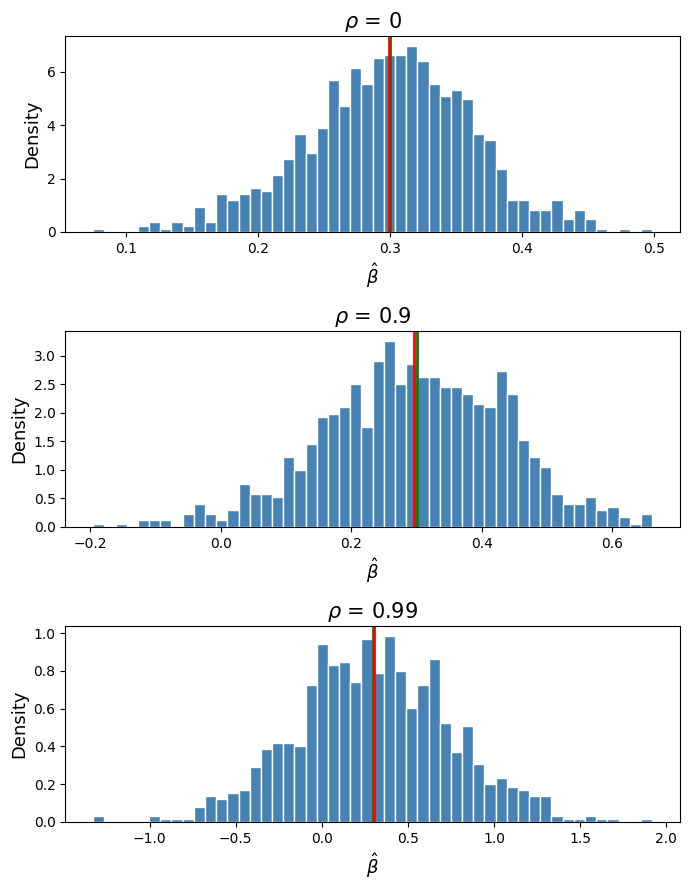

In [6]:
names = [r'$\sigma^{2}_{\epsilon}$', r'$\sigma^{2}_{x_{1}}$', r'$\rho$']

# Data Generating process values:
grid_sigma_e  = [0.01, 0.3, 0.6, 1, 2.6, 3]
grid_sigma_x1 = [0.01, 0.1, 0.8, 1.6, 2, 2.5]
grid_rho      = [0, 0.6, 0.9, 0.95, 0.99, 1]

# Default Values:
n  = 100        # Sample size
ns = 1000        # Number of Montecarlo Samples

mean_x1, mean_x2 = 20.0, 27.0
variance_x2 = 1.4
beta0, beta1, beta2 = 2.0, 0.3, 1.5

mu_beta = np.full((6, 3), np.nan)
mu_SEbeta = np.full((6, 3), np.nan)

rng = np.random.default_rng(999)

for i in range(3):        # which parameter is being varied: 0=sigma_e, 1=sigma_x1, 2=rho
    it = -1
    fig, axes = plt.subplots(3, 1, figsize=(7, 9))
    # Defaults, reset for each parameter sweep:
    variance_e  = grid_sigma_e[1]
    variance_x1 = grid_sigma_x1[2]
    rho         = grid_rho[0]

    for ii in range(6):
        if i == 0:
            variance_e = grid_sigma_e[ii]
            name_val = variance_e
        elif i == 1:
            variance_x1 = grid_sigma_x1[ii]
            name_val = variance_x1
        else:
            rho = grid_rho[ii]
            name_val = rho

        # Simulate the Correlated Variables
        cov_x1x2 = np.sqrt(variance_x1) * np.sqrt(variance_x2) * rho
        big_sigma = np.array([[variance_x1, cov_x1x2], [cov_x1x2, variance_x2]])

        beta1_hat = np.full(ns, np.nan)
        SE_beta_hat = np.full(ns, np.nan)

        for oo in range(ns):
            # Generate the data
            err = 0 + np.sqrt(variance_e) * rng.standard_normal(n)
            X_draw = rng.multivariate_normal([mean_x1, mean_x2], big_sigma, size=n)
            y_draw = beta0 + beta1 * X_draw[:, 0] + beta2 * X_draw[:, 1] + err
            # Estimate OLS
            try:
                X_design = np.column_stack([np.ones(n), X_draw])
                res = ols_esti(y_draw, X_design)
                SE_beta_hat[oo] = res['SEbeta_hat'][1]
                beta1_hat[oo] = res['beta_hat'][1]
            except ValueError:
                if oo == 0:
                    print('Perfect Colinearity, check your variables!')
                SE_beta_hat[:] = np.nan
                beta1_hat[:] = np.nan
                break

        # Compute and save the mean of the OLS estimator
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', category=RuntimeWarning)
            mu_beta[ii, i] = np.nanmean(beta1_hat)
            mu_SEbeta[ii, i] = np.nanmean(SE_beta_hat)

        # Plot the Histograms
        if ii in (0, 2, 4):
            it += 1
            ax = axes[it]
            ax.hist(beta1_hat, bins=num_bins, density=True, color='steelblue', edgecolor='white')
            ax.axvline(beta1, color='g', linewidth=2)
            ax.axvline(mu_beta[ii, i], color='r', linewidth=2)
            ax.set_ylabel('Density', fontsize=13)
            ax.set_xlabel(r'$\hat{\beta}$', fontsize=13)
            ax.set_title(f'{names[i]} = {name_val}', fontsize=15)

    plt.tight_layout()
    plt.show()


The consequences of collinearity

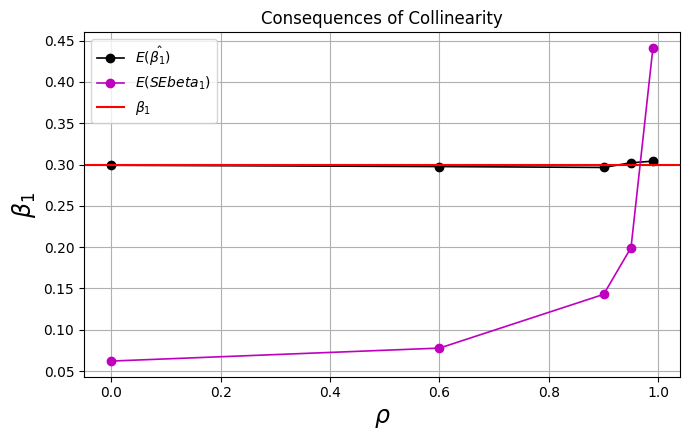

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(grid_rho, mu_beta[:, 2], 'ko-', markerfacecolor='k', linewidth=1.2, label=r'$E(\hat{\beta_{1}})$')
ax.plot(grid_rho, mu_SEbeta[:, 2], 'mo-', markerfacecolor='m', linewidth=1.2, label=r'$E(SEbeta_{1})$')
ax.axhline(beta1, color='r', label=r'$\beta_{1}$')
ax.set_ylabel(r'$\beta_{1}$', fontsize=17)
ax.set_xlabel(r'$\rho$', fontsize=17)
ax.grid(True)
ax.legend()
ax.set_title('Consequences of Collinearity')
plt.tight_layout()
plt.show()


Consequences of not having enough variation for identification

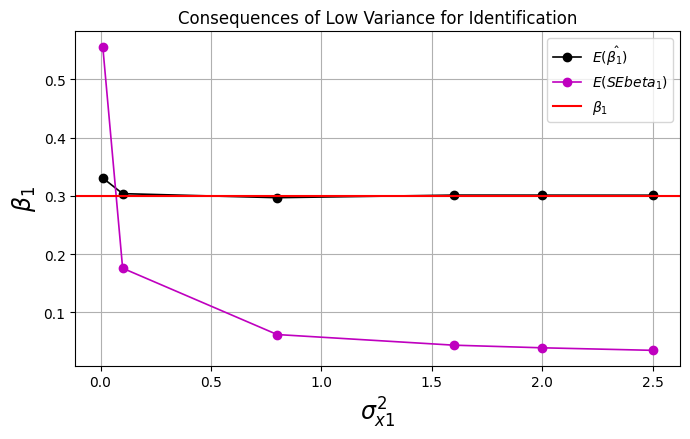

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(grid_sigma_x1, mu_beta[:, 1], 'ko-', markerfacecolor='k', linewidth=1.2, label=r'$E(\hat{\beta_{1}})$')
ax.plot(grid_sigma_x1, mu_SEbeta[:, 1], 'mo-', markerfacecolor='m', linewidth=1.2, label=r'$E(SEbeta_{1})$')
ax.axhline(beta1, color='r', label=r'$\beta_{1}$')
ax.set_ylabel(r'$\beta_{1}$', fontsize=17)
ax.set_xlabel(r'$\sigma^{2}_{x1}$', fontsize=17)
ax.grid(True)
ax.legend()
ax.set_title('Consequences of Low Variance for Identification')
plt.tight_layout()
plt.show()


No consequences of having a larger variance of the error

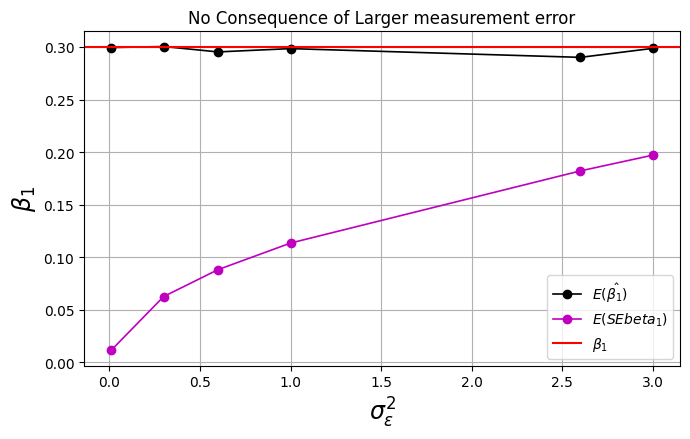

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(grid_sigma_e, mu_beta[:, 0], 'ko-', markerfacecolor='k', linewidth=1.2, label=r'$E(\hat{\beta_{1}})$')
ax.plot(grid_sigma_e, mu_SEbeta[:, 0], 'mo-', markerfacecolor='m', linewidth=1.2, label=r'$E(SEbeta_{1})$')
ax.axhline(beta1, color='r', label=r'$\beta_{1}$')
ax.set_ylabel(r'$\beta_{1}$', fontsize=17)
ax.set_xlabel(r'$\sigma^{2}_{\epsilon}$', fontsize=17)
ax.grid(True)
ax.legend()
ax.set_title('No Consequence of Larger measurement error')
plt.tight_layout()
plt.show()


This markdown was constructed based on the IPYNB code below.

In [10]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from scipy import stats
# import statsmodels.api as sm
# import warnings
#
# rng = np.random.default_rng(1234)   # Set seed for reproducibility
#
# # Plot options
# num_bins = 50
#
# N  = 1_000_000     # Our Universe
# NS = 50             # Size of our sample
# MS = 1000           # Number of samples
# sigma = [0.1, 0.5]
# mu = 4
#
# x_vec = np.empty((N, 2))
# x_sample = np.empty((NS, MS, 2))
# x_mean = np.empty((MS, 2))
# y_sample = np.empty((NS, MS, 2))
# y_mean = np.empty((MS, 2))
#
# for i in range(2):
#     x_vec[:, i] = mu + sigma[i] * rng.standard_normal(N)
#
#     # With loop: generate NS samples from the universe
#     for j in range(MS):
#         x_sample[:, j, i] = rng.choice(x_vec[:, i], size=NS, replace=False)
#         x_mean[j, i] = x_sample[:, j, i].mean()
#
#     # Without a loop, purely for Montecarlo purposes:
#     y_sample[:, :, i] = mu + sigma[i] * rng.standard_normal((NS, MS))
#     y_mean[:, i] = y_sample[:, :, i].mean(axis=0)
#
# # Plot the Distribution of Means and the true mean
# fig, axes = plt.subplots(2, 1, figsize=(7, 8))
# for i in range(2):
#     ax = axes[i]
#     ax.hist(x_mean[:, i], bins=num_bins, density=True, color='steelblue', edgecolor='white')
#     ax.axvline(mu, color='g', linewidth=2, label='True')
#     ax.axvline(x_mean[:, i].mean(), color='r', linewidth=2, label='Estimated')
#     ax.set_title(rf'$\sigma^{{2}} = ${round(sigma[i]**2, 6)}', fontsize=17)
#     ax.set_xlim(3.7, 4.3)
#     ax.set_ylabel('pdf')
#     ax.legend(['Dist of the Mean', 'True', 'Estimated'])
# plt.tight_layout()
# plt.show()
#
#
# # ----- next cell -----
#
# rng = np.random.default_rng(567)   # Set seed for reproducibility
#
# sigma_gp = 0.1   # Scale
# k_gp = 0.8       # Index, shape
# theta_gp = 0     # Threshold, location
# x_vec = stats.genpareto.rvs(c=k_gp, loc=theta_gp, scale=sigma_gp, size=N, random_state=rng)
#
# MS = 2000
# NS = 200          # Size of our sample
# mu_A = theta_gp + (2**k_gp - 1) * sigma_gp / k_gp
# mu_B = theta_gp + sigma_gp / (1 - k_gp)
#
# x_sample = np.empty((NS, MS))
# x_mean = np.empty(MS)
# x_median = np.empty(MS)
#
# # Plot the histogram of the distribution of the Universe
# mask = x_vec <= 4
# fig, ax = plt.subplots(figsize=(7, 4.5))
# ax.hist(x_vec[mask], bins=num_bins, density=True, color='steelblue', edgecolor='white', label='Distribution of the Universe')
# ax.set_ylabel('pdf')
# ax.legend()
# plt.tight_layout()
# plt.show()
#
# for j in range(MS):
#     x_sample[:, j] = rng.choice(x_vec, size=NS, replace=False)
#     x_median[j] = np.median(x_sample[:, j])
#     x_mean[j] = x_sample[:, j].mean()
#
#
# # ----- next cell -----
#
# fig, ax = plt.subplots(figsize=(7, 4.5))
# ax.hist(x_median, bins=num_bins, density=True, color='steelblue', edgecolor='white')
# ax.axvline(mu_A, color='g', linewidth=2)
# ax.axvline(x_median.mean(), color='r', linewidth=2)
# ax.set_ylabel('pdf')
# ax.legend(['Dist of the Median', 'True', 'Estimated'])
# plt.tight_layout()
# plt.show()
#
#
# # ----- next cell -----
#
# def ols_esti(y, X):
#     '''
#     This function computes the Least Squares Estimate
#     Input:
#     y: Dependent Variable    (N,1)
#     X: Independent Variables (N,K)
#     Output:
#     Many stuff you saw in class.
#     '''
#     y = np.asarray(y, dtype=float)
#     X = np.asarray(X, dtype=float)
#     Nx, K = X.shape
#     Ny = y.shape[0]
#     if Ny != Nx:
#         raise ValueError('X and y do not have the same length')
#     if np.linalg.matrix_rank(X.T @ X) != K:
#         raise ValueError('Not complete Rank, Perfect Colinearity')
#     N = Nx
#
#     # Coefficients:
#     beta_hat = np.linalg.inv(X.T @ X) @ (X.T @ y)
#     # Predicted values:
#     y_hat = X @ beta_hat
#     # Residuals:
#     e_hat = y - y_hat
#     # Total Variation of the dependent variable
#     SST = (y - y.mean()) @ (y - y.mean())
#     # (SSE) Sum Squared Residuals
#     SSE = e_hat @ e_hat
#     # SSR/SST or "r-squared" is the ratio of the variation in y explained by the model and the total variation of y
#     R2 = 1 - (SSE / SST)
#     # Adjusted "r-squared".
#     R2A = 1 - (SSE / (N - K)) / (SST / (N - 1))
#     sigma2_hat = SSE / (N - K)
#
#     var_covar = sigma2_hat * np.linalg.inv(X.T @ X)
#     SEbeta_hat = np.sqrt(np.diag(var_covar))
#
#     return {
#         'beta_hat': beta_hat, 'y_hat': y_hat, 'e_hat': e_hat,
#         'SST': SST, 'SSE': SSE, 'R2': R2, 'R2A': R2A, 'sigma2_hat': sigma2_hat,
#         'var_covar': var_covar, 'SEbeta_hat': SEbeta_hat,
#     }
#
# rng = np.random.default_rng(4567)
#
# n = 500
# mean_x1, variance_x = 4.0, 2.0
# variance_e = [0.1, 0.3, 0.8]
# x = mean_x1 + np.sqrt(variance_x) * rng.standard_normal(n)
#
# beta0, beta1 = 2.0, 0.5
#
# err = np.empty((n, 3))
# y = np.empty((n, 3))
# X_design = np.column_stack([np.ones(n), x])
# results = []
# for i in range(3):
#     err[:, i] = 0 + np.sqrt(variance_e[i]) * rng.standard_normal(n)
#     # Simulate Data Generating Process:
#     y[:, i] = beta0 + beta1 * x + err[:, i]
#     # Estimate the OLS and back out the Residuals
#     results.append(ols_esti(y[:, i], X_design))
#
# for i in range(3):
#     fig, ax = plt.subplots(figsize=(6, 4.2))
#     ax.plot(x, y[:, i], 'kx')
#     ax.plot(x, results[i]['y_hat'], 'b-', linewidth=1.1)
#     ax.set_ylim(0, 8)
#     ax.grid(True)
#     ax.set_xlabel('$x$', fontsize=14)
#     ax.set_ylabel('$y$', fontsize=14)
#     ax.set_title(rf'$\sigma^{{2}} = ${variance_e[i]}', fontsize=15)
#     plt.tight_layout()
#     plt.show()
#
#
# # ----- next cell -----
#
# fig, axes = plt.subplots(3, 1, figsize=(7, 9))
# xlims = [(-1.6, 1.6), (-1.6, 1.6), (-3, 3)]
# for i in range(3):
#     ax = axes[i]
#     e_hat = results[i]['e_hat']
#     ax.hist(e_hat, bins=num_bins, density=True, color='steelblue', edgecolor='white')
#     ax.grid(True)
#     ax.set_ylabel('Density', fontsize=13)
#     ax.set_xlabel(r'$\hat{e}$', fontsize=13)
#     ax.set_title(rf'$\sigma^{{2}}$ = {variance_e[i]}  $\hat{{\sigma}}^{{2}}$ = {round(e_hat.var(ddof=0), 4)}', fontsize=14)
#     ax.set_xlim(xlims[i])
# plt.tight_layout()
# plt.show()
#
#
# # ----- next cell -----
#
# names = [r'$\sigma^{2}_{\epsilon}$', r'$\sigma^{2}_{x_{1}}$', r'$\rho$']
#
# # Data Generating process values:
# grid_sigma_e  = [0.01, 0.3, 0.6, 1, 2.6, 3]
# grid_sigma_x1 = [0.01, 0.1, 0.8, 1.6, 2, 2.5]
# grid_rho      = [0, 0.6, 0.9, 0.95, 0.99, 1]
#
# # Default Values:
# n  = 100        # Sample size
# ns = 1000        # Number of Montecarlo Samples
#
# mean_x1, mean_x2 = 20.0, 27.0
# variance_x2 = 1.4
# beta0, beta1, beta2 = 2.0, 0.3, 1.5
#
# mu_beta = np.full((6, 3), np.nan)
# mu_SEbeta = np.full((6, 3), np.nan)
#
# rng = np.random.default_rng(999)
#
# for i in range(3):        # which parameter is being varied: 0=sigma_e, 1=sigma_x1, 2=rho
#     it = -1
#     fig, axes = plt.subplots(3, 1, figsize=(7, 9))
#     # Defaults, reset for each parameter sweep:
#     variance_e  = grid_sigma_e[1]
#     variance_x1 = grid_sigma_x1[2]
#     rho         = grid_rho[0]
#
#     for ii in range(6):
#         if i == 0:
#             variance_e = grid_sigma_e[ii]
#             name_val = variance_e
#         elif i == 1:
#             variance_x1 = grid_sigma_x1[ii]
#             name_val = variance_x1
#         else:
#             rho = grid_rho[ii]
#             name_val = rho
#
#         # Simulate the Correlated Variables
#         cov_x1x2 = np.sqrt(variance_x1) * np.sqrt(variance_x2) * rho
#         big_sigma = np.array([[variance_x1, cov_x1x2], [cov_x1x2, variance_x2]])
#
#         beta1_hat = np.full(ns, np.nan)
#         SE_beta_hat = np.full(ns, np.nan)
#
#         for oo in range(ns):
#             # Generate the data
#             err = 0 + np.sqrt(variance_e) * rng.standard_normal(n)
#             X_draw = rng.multivariate_normal([mean_x1, mean_x2], big_sigma, size=n)
#             y_draw = beta0 + beta1 * X_draw[:, 0] + beta2 * X_draw[:, 1] + err
#             # Estimate OLS
#             try:
#                 X_design = np.column_stack([np.ones(n), X_draw])
#                 res = ols_esti(y_draw, X_design)
#                 SE_beta_hat[oo] = res['SEbeta_hat'][1]
#                 beta1_hat[oo] = res['beta_hat'][1]
#             except ValueError:
#                 if oo == 0:
#                     print('Perfect Colinearity, check your variables!')
#                 SE_beta_hat[:] = np.nan
#                 beta1_hat[:] = np.nan
#                 break
#
#         # Compute and save the mean of the OLS estimator
#         with warnings.catch_warnings():
#             warnings.simplefilter('ignore', category=RuntimeWarning)
#             mu_beta[ii, i] = np.nanmean(beta1_hat)
#             mu_SEbeta[ii, i] = np.nanmean(SE_beta_hat)
#
#         # Plot the Histograms
#         if ii in (0, 2, 4):
#             it += 1
#             ax = axes[it]
#             ax.hist(beta1_hat, bins=num_bins, density=True, color='steelblue', edgecolor='white')
#             ax.axvline(beta1, color='g', linewidth=2)
#             ax.axvline(mu_beta[ii, i], color='r', linewidth=2)
#             ax.set_ylabel('Density', fontsize=13)
#             ax.set_xlabel(r'$\hat{\beta}$', fontsize=13)
#             ax.set_title(f'{names[i]} = {name_val}', fontsize=15)
#
#     plt.tight_layout()
#     plt.show()
#
#
# # ----- next cell -----
#
# fig, ax = plt.subplots(figsize=(7, 4.5))
# ax.plot(grid_rho, mu_beta[:, 2], 'ko-', markerfacecolor='k', linewidth=1.2, label=r'$E(\hat{\beta_{1}})$')
# ax.plot(grid_rho, mu_SEbeta[:, 2], 'mo-', markerfacecolor='m', linewidth=1.2, label=r'$E(SEbeta_{1})$')
# ax.axhline(beta1, color='r', label=r'$\beta_{1}$')
# ax.set_ylabel(r'$\beta_{1}$', fontsize=17)
# ax.set_xlabel(r'$\rho$', fontsize=17)
# ax.grid(True)
# ax.legend()
# ax.set_title('Consequences of Collinearity')
# plt.tight_layout()
# plt.show()
#
#
# # ----- next cell -----
#
# fig, ax = plt.subplots(figsize=(7, 4.5))
# ax.plot(grid_sigma_x1, mu_beta[:, 1], 'ko-', markerfacecolor='k', linewidth=1.2, label=r'$E(\hat{\beta_{1}})$')
# ax.plot(grid_sigma_x1, mu_SEbeta[:, 1], 'mo-', markerfacecolor='m', linewidth=1.2, label=r'$E(SEbeta_{1})$')
# ax.axhline(beta1, color='r', label=r'$\beta_{1}$')
# ax.set_ylabel(r'$\beta_{1}$', fontsize=17)
# ax.set_xlabel(r'$\sigma^{2}_{x1}$', fontsize=17)
# ax.grid(True)
# ax.legend()
# ax.set_title('Consequences of Low Variance for Identification')
# plt.tight_layout()
# plt.show()
#
#
# # ----- next cell -----
#
# fig, ax = plt.subplots(figsize=(7, 4.5))
# ax.plot(grid_sigma_e, mu_beta[:, 0], 'ko-', markerfacecolor='k', linewidth=1.2, label=r'$E(\hat{\beta_{1}})$')
# ax.plot(grid_sigma_e, mu_SEbeta[:, 0], 'mo-', markerfacecolor='m', linewidth=1.2, label=r'$E(SEbeta_{1})$')
# ax.axhline(beta1, color='r', label=r'$\beta_{1}$')
# ax.set_ylabel(r'$\beta_{1}$', fontsize=17)
# ax.set_xlabel(r'$\sigma^{2}_{\epsilon}$', fontsize=17)
# ax.grid(True)
# ax.legend()
# ax.set_title('No Consequence of Larger measurement error')
# plt.tight_layout()
# plt.show()